In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("train_FD001.csv")

columns = [
    'unit_number', 'time_in_cycles',
    'operational_setting_1', 'operational_setting_2', 'operational_setting_3',
    'sensor_measurement_1', 'sensor_measurement_2', 'sensor_measurement_3',
    'sensor_measurement_4', 'sensor_measurement_5', 'sensor_measurement_6',
    'sensor_measurement_7', 'sensor_measurement_8', 'sensor_measurement_9',
    'sensor_measurement_10', 'sensor_measurement_11', 'sensor_measurement_12',
    'sensor_measurement_13', 'sensor_measurement_14', 'sensor_measurement_15',
    'sensor_measurement_16', 'sensor_measurement_17', 'sensor_measurement_18',
    'sensor_measurement_19', 'sensor_measurement_20', 'sensor_measurement_21'
]

df.columns = columns

# -------------------------------
# 2. COMPUTE RUL
# -------------------------------
max_cycle = df.groupby("unit_number")["time_in_cycles"].max().reset_index()
max_cycle.columns = ["unit_number", "max_cycle"]

df = df.merge(max_cycle, on="unit_number")
df["RUL"] = df["max_cycle"] - df["time_in_cycles"]
print(df)
df.to_csv("train_FD001_with_RUL.csv", index=False)

       unit_number  time_in_cycles  operational_setting_1  \
0                1               1                -0.0007   
1                1               2                 0.0019   
2                1               3                -0.0043   
3                1               4                 0.0007   
4                1               5                -0.0019   
...            ...             ...                    ...   
20626          100             196                -0.0004   
20627          100             197                -0.0016   
20628          100             198                 0.0004   
20629          100             199                -0.0011   
20630          100             200                -0.0032   

       operational_setting_2  operational_setting_3  sensor_measurement_1  \
0                    -0.0004                  100.0                518.67   
1                    -0.0003                  100.0                518.67   
2                     0.0003        

In [4]:
# df → full dataframe (with id, cycle, sensors, RUL)
X = df.drop(columns=['unit_number', 'time_in_cycles', 'RUL'])
y = df['RUL']
from sklearn.feature_selection import VarianceThreshold

var_selector = VarianceThreshold(threshold=0.01)
X_var = var_selector.fit_transform(X)

X_var = pd.DataFrame(
    X_var,
    columns=X.columns[var_selector.get_support()]
)

print("After variance threshold:", X_var.shape)

After variance threshold: (20631, 12)


In [6]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


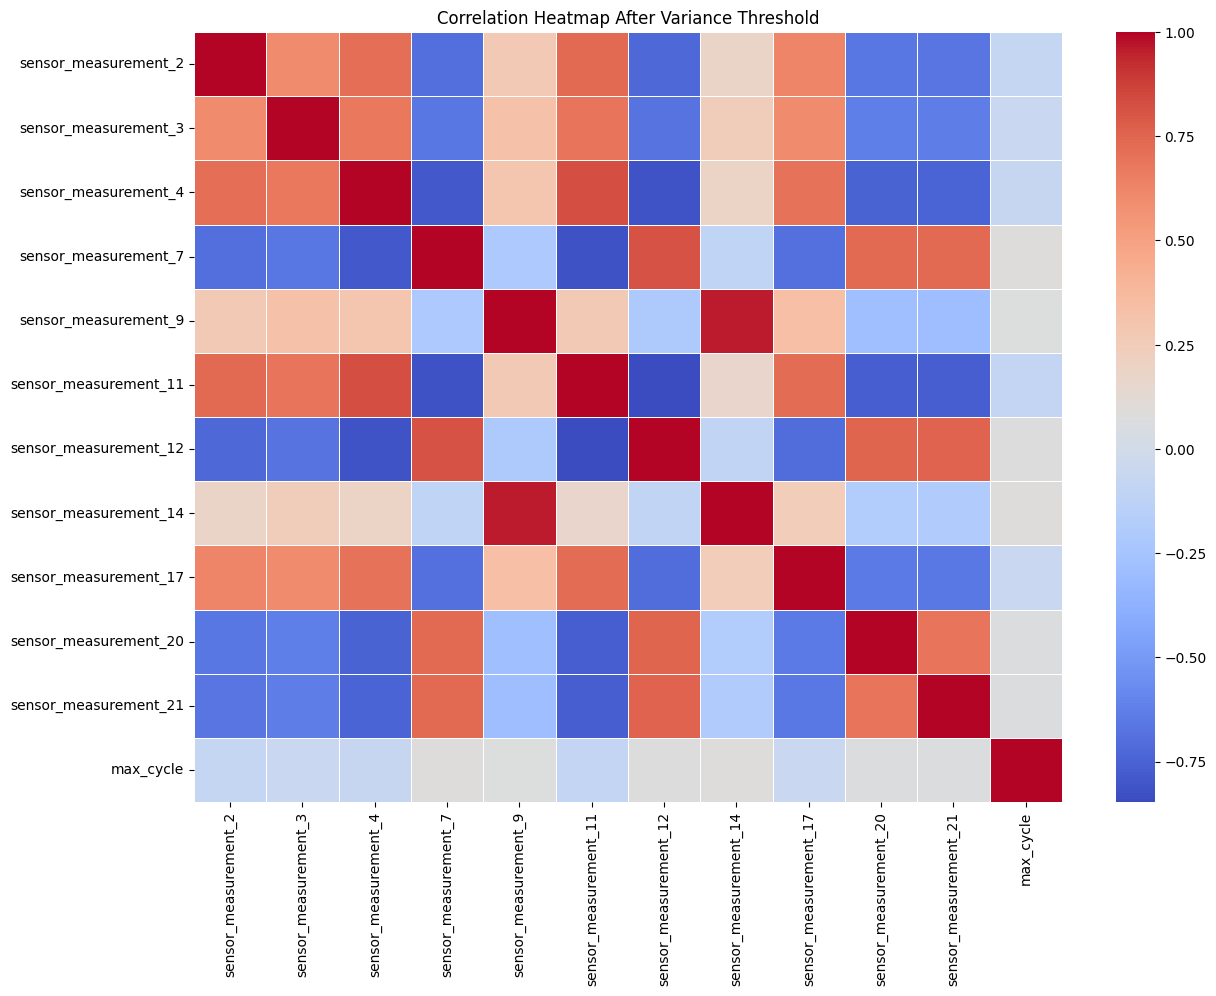

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_var.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.4)
plt.title("Correlation Heatmap After Variance Threshold")
plt.show()

In [9]:
import numpy as np
corr_threshold = 0.95

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop_corr = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column].abs() > corr_threshold)
]

print("Highly correlated features to drop:", to_drop_corr)

Highly correlated features to drop: ['sensor_measurement_14']


In [10]:
X_selected = X_var.drop(columns=to_drop_corr)

print("After correlation filtering:", X_selected.shape)

After correlation filtering: (20631, 11)


In [14]:
df_selected = pd.concat(
    [df[['unit_number', 'time_in_cycles']], X_selected, y],
    axis=1
)


In [15]:
from sklearn.preprocessing import MinMaxScaler

features = df.columns.difference(['unit_number','time_in_cycles','RUL'])
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [ ]:
df_selected.to_csv(
    "TRAIN_FD001_preprocessed_scaled.csv",
    index=False
)

print("Preprocessed & scaled TRAIN_FD001 saved successfully")

✅ Preprocessed & scaled TRAIN_FD001 saved successfully
